In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Stil ayarları
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [ ]:
# Veriyi yükle
SHEET_URL = "https://docs.google.com/spreadsheets/d/1DTiCcgayObrMaX8wkFaqMcx1ibtOI_-cgCv9VdRDxBk/export?format=csv&gid=1391075340"
data = pd.read_csv(SHEET_URL)

print("🎓 ÖĞRENCİ BAŞARI ANALİZİ")
print("=" * 50)
print(f"✅ Veri başarıyla yüklendi! Toplam kayıt: {len(data)} öğrenci")
print("=" * 50)

🎓 ÖĞRENCİ BAŞARI ANALİZİ
✅ Veri başarıyla yüklendi! Toplam kayıt: 12 öğrenci



📊 VERİ ÖNİZLEME:


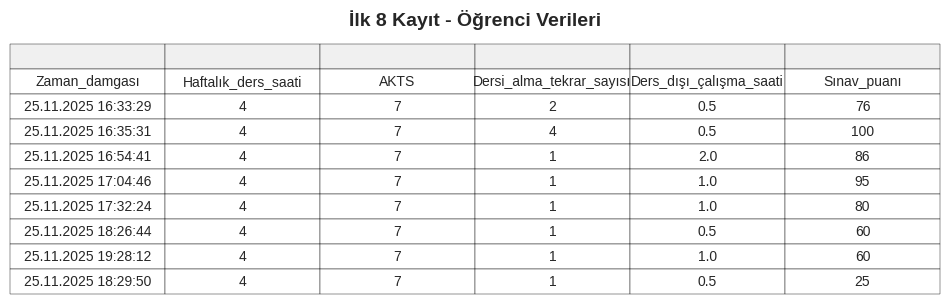

In [ ]:
# Veri Önizleme - Daha Güzel Tablo
print("\n📊 VERİ ÖNİZLEME:")
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('tight')
ax.axis('off')
table_data = [data.columns.tolist()] + data.head(8).values.tolist()
table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                 colColours=['#f0f0f0']*len(data.columns))
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
plt.title('İlk 8 Kayıt - Öğrenci Verileri', fontsize=14, fontweight='bold', pad=20)
plt.show()


📈 TEMEL İSTATİSTİKLER:


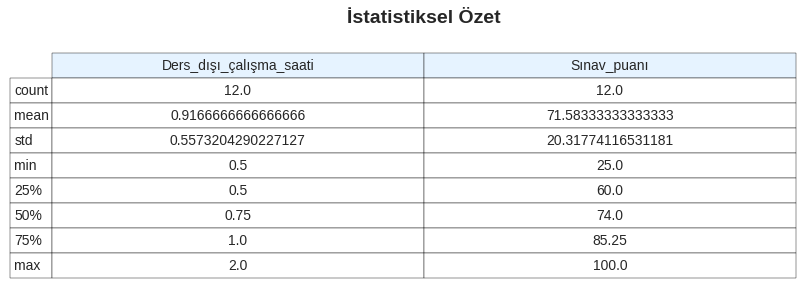

In [ ]:
# İstatistiksel Özet - Görsel Tablo
print("\n📈 TEMEL İSTATİSTİKLER:")
stats = data[['Ders_dışı_çalışma_saati', 'Sınav_puanı']].describe()
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=stats.values, rowLabels=stats.index,
                 colLabels=stats.columns, cellLoc='center', loc='center',
                 colColours=['#e6f3ff']*len(stats.columns))
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
plt.title('İstatistiksel Özet', fontsize=14, fontweight='bold', pad=20)
plt.show()

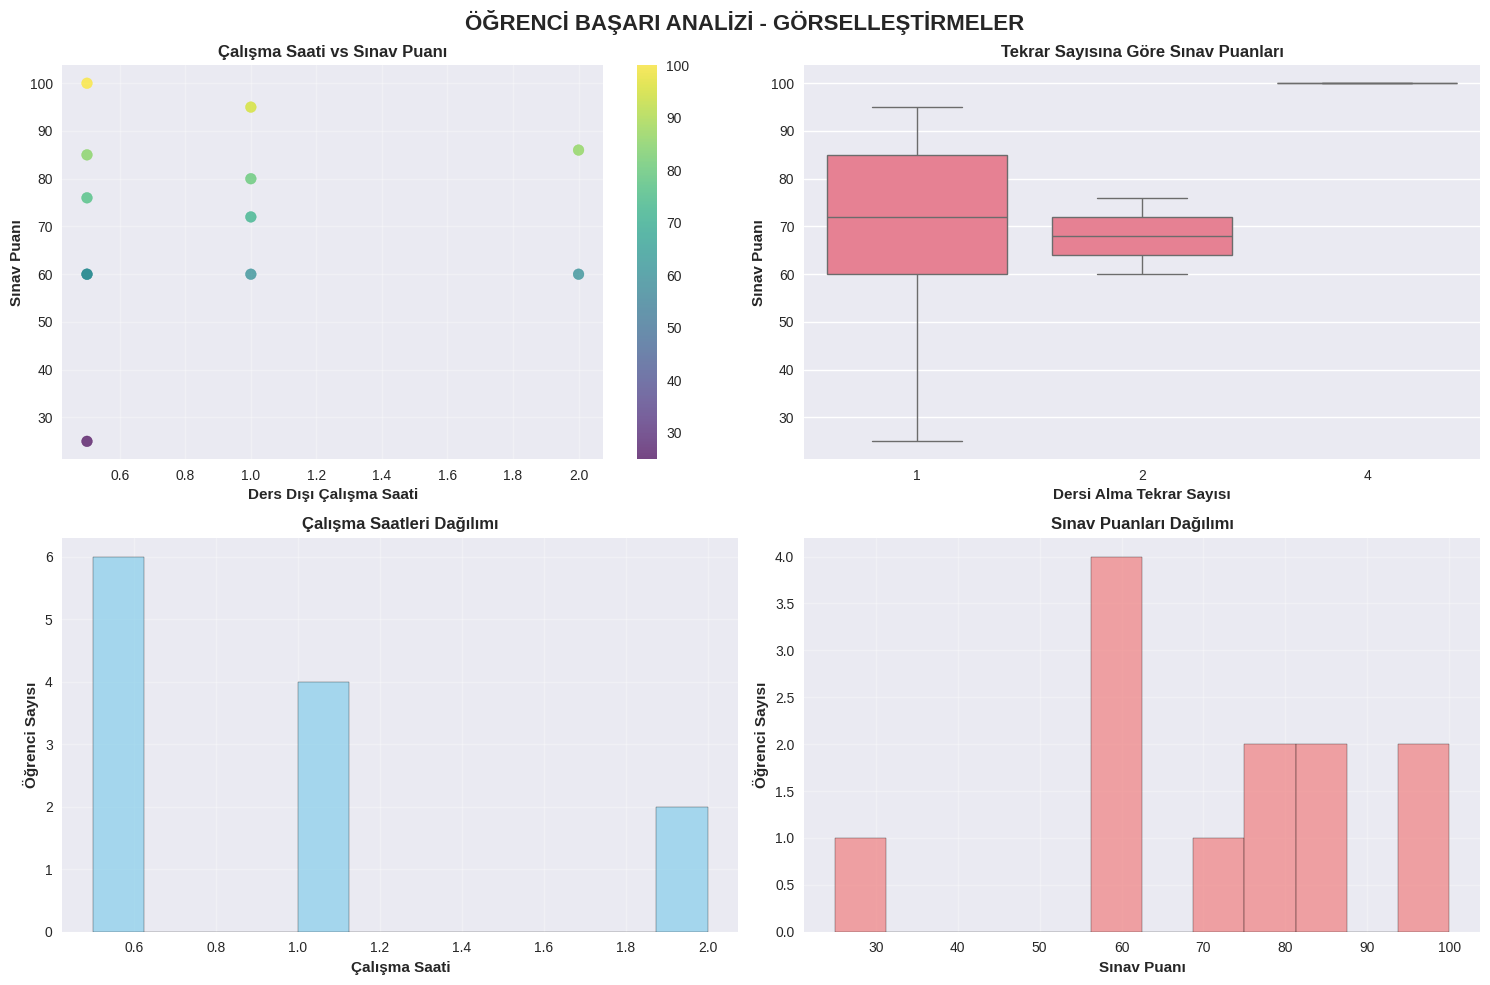

In [ ]:
# Gelişmiş Görselleştirme
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('ÖĞRENCİ BAŞARI ANALİZİ - GÖRSELLEŞTİRMELER', fontsize=16, fontweight='bold')

# 1. Ana scatter plot
scatter = axes[0,0].scatter(data['Ders_dışı_çalışma_saati'], data['Sınav_puanı'],
                           c=data['Sınav_puanı'], cmap='viridis', alpha=0.7, s=60)
axes[0,0].set_xlabel('Ders Dışı Çalışma Saati', fontweight='bold')
axes[0,0].set_ylabel('Sınav Puanı', fontweight='bold')
axes[0,0].set_title('Çalışma Saati vs Sınav Puanı', fontweight='bold')
axes[0,0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0,0])

# 2. Tekrar sayısı boxplot
sns.boxplot(data=data, x='Dersi_alma_tekrar_sayısı', y='Sınav_puanı', ax=axes[0,1])
axes[0,1].set_xlabel('Dersi Alma Tekrar Sayısı', fontweight='bold')
axes[0,1].set_ylabel('Sınav Puanı', fontweight='bold')
axes[0,1].set_title('Tekrar Sayısına Göre Sınav Puanları', fontweight='bold')

# 3. Çalışma saati dağılımı
axes[1,0].hist(data['Ders_dışı_çalışma_saati'], bins=12, color='skyblue',
               edgecolor='black', alpha=0.7)
axes[1,0].set_xlabel('Çalışma Saati', fontweight='bold')
axes[1,0].set_ylabel('Öğrenci Sayısı', fontweight='bold')
axes[1,0].set_title('Çalışma Saatleri Dağılımı', fontweight='bold')
axes[1,0].grid(True, alpha=0.3)

# 4. Sınav puanı dağılımı
axes[1,1].hist(data['Sınav_puanı'], bins=12, color='lightcoral',
               edgecolor='black', alpha=0.7)
axes[1,1].set_xlabel('Sınav Puanı', fontweight='bold')
axes[1,1].set_ylabel('Öğrenci Sayısı', fontweight='bold')
axes[1,1].set_title('Sınav Puanları Dağılımı', fontweight='bold')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# REGRESYON ANALİZLERİ
print("\n" + "="*60)
print("🤖 REGRESYON MODELLERİ ANALİZİ")
print("="*60)

X = data[['Ders_dışı_çalışma_saati']]
y = data['Sınav_puanı']

models = {
    "Linear Regression": LinearRegression(),
    "Polynomial Regression": Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('linear', LinearRegression())
    ]),
    "Decision Tree Regression": DecisionTreeRegressor(max_depth=3, random_state=42)
}


🤖 REGRESYON MODELLERİ ANALİZİ


In [ ]:
# Model eğitimi ve sonuçlar
results = {}
print("\n📊 MODEL PERFORMANS KARŞILAŞTIRMASI:")
print("-" * 50)

for name, model in models.items():
    model.fit(X, y)
    y_pred = model.predict(X)
    results[name] = {
        'model': model,
        'r2_score': r2_score(y, y_pred),
        'mse': mean_squared_error(y, y_pred)
    }

    # Renkli performans göstergesi
    r2 = results[name]['r2_score']
    if r2 > 0.7:
        r2_indicator = "🟢 MÜKEMMEL"
    elif r2 > 0.5:
        r2_indicator = "🟡 İYİ"
    elif r2 > 0.3:
        r2_indicator = "🟠 ORTA"
    else:
        r2_indicator = "🔴 ZAYIF"

    print(f"🎯 {name:25} R² = {r2:6.4f} {r2_indicator:15} MSE = {results[name]['mse']:7.2f}")

# TAHMİNLER - Görsel Tablo
print("\n" + "="*60)
print("🔮 GELECEK TAHMİNLERİ")
print("="*60)

study_hours_to_predict = pd.DataFrame([0.5, 1.0, 1.5, 2.0], columns=['Ders_dışı_çalışma_saati'])


📊 MODEL PERFORMANS KARŞILAŞTIRMASI:
--------------------------------------------------
🎯 Linear Regression         R² = 0.0137 🔴 ZAYIF         MSE =  373.22
🎯 Polynomial Regression     R² = 0.0447 🔴 ZAYIF         MSE =  361.51
🎯 Decision Tree Regression  R² = 0.0447 🔴 ZAYIF         MSE =  361.51

🔮 GELECEK TAHMİNLERİ


In [ ]:
# Tahmin tablosu oluştur
prediction_data = []
for index, row in study_hours_to_predict.iterrows():
    hours = row['Ders_dışı_çalışma_saati']
    row_data = [f"{hours} saat"]
    for name, result in results.items():
        pred = result['model'].predict(study_hours_to_predict.iloc[[index]])
        row_data.append(f"{pred[0]:.1f} puan")
    prediction_data.append(row_data)

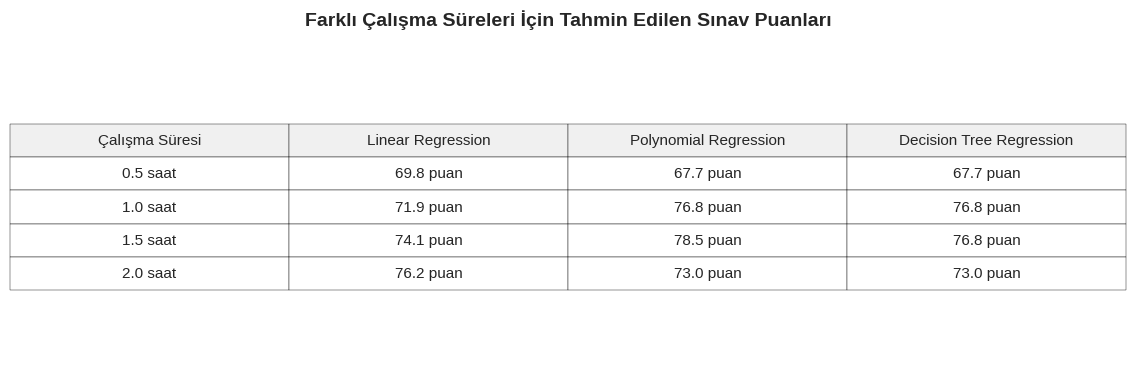

In [ ]:
# Tahmin tablosunu göster
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('tight')
ax.axis('off')
columns = ['Çalışma Süresi'] + list(models.keys())
table = ax.table(cellText=prediction_data, colLabels=columns,
                 cellLoc='center', loc='center',
                 colColours=['#f0f0f0']*len(columns))
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)
plt.title('Farklı Çalışma Süreleri İçin Tahmin Edilen Sınav Puanları',
          fontsize=14, fontweight='bold', pad=20)
plt.show()


📈 REGRESYON MODELLERİ GÖRSELLEŞTİRMESİ


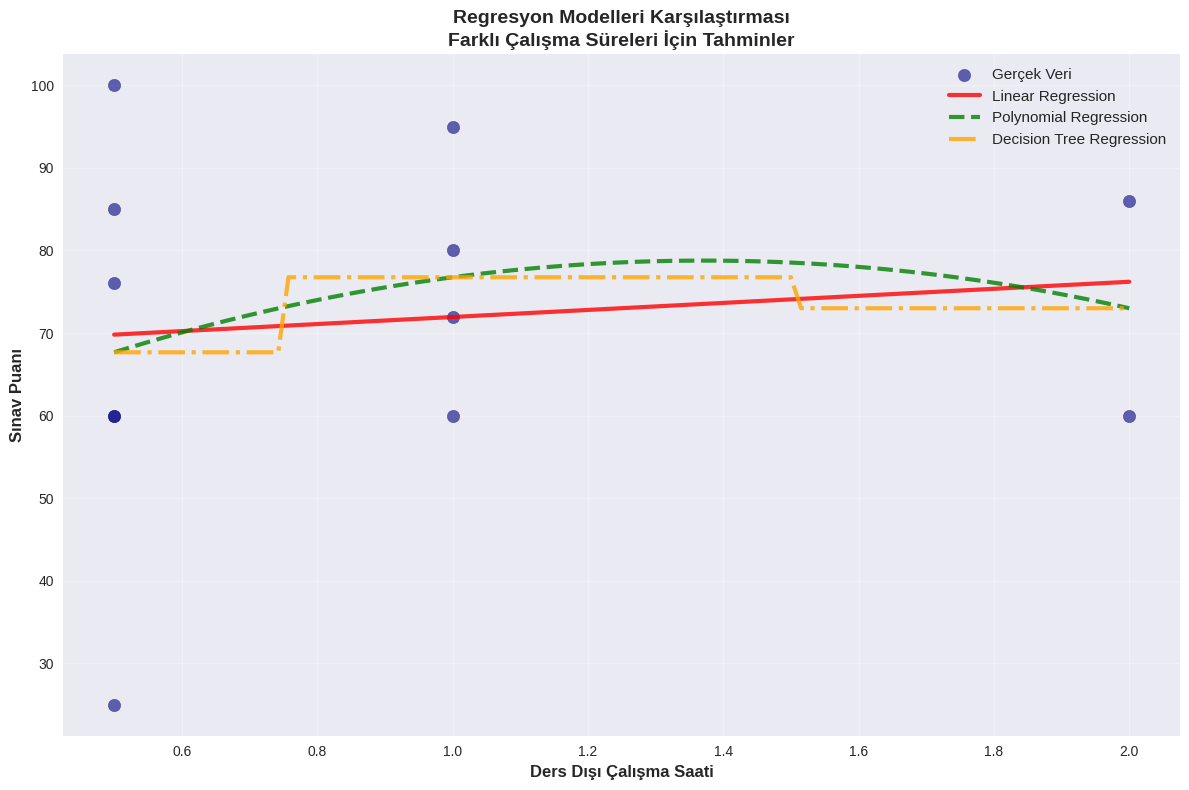

In [ ]:
# REGRESYON GÖRSELLEŞTİRME
print("\n" + "="*60)
print("📈 REGRESYON MODELLERİ GÖRSELLEŞTİRMESİ")
print("="*60)

plt.figure(figsize=(12, 8))

# Gerçek veri noktaları
plt.scatter(data['Ders_dışı_çalışma_saati'], data['Sınav_puanı'],
            alpha=0.6, s=80, label='Gerçek Veri', color='navy')

# Regresyon çizgileri
x_range = np.linspace(data['Ders_dışı_çalışma_saati'].min(),
                      data['Ders_dışı_çalışma_saati'].max(), 100)
x_range_df = pd.DataFrame(x_range, columns=['Ders_dışı_çalışma_saati'])

colors = ['red', 'green', 'orange']
line_styles = ['-', '--', '-.']
for (name, result), color, style in zip(results.items(), colors, line_styles):
    y_range = result['model'].predict(x_range_df)
    plt.plot(x_range, y_range, label=name, color=color,
             linewidth=3, linestyle=style, alpha=0.8)

plt.xlabel('Ders Dışı Çalışma Saati', fontsize=12, fontweight='bold')
plt.ylabel('Sınav Puanı', fontsize=12, fontweight='bold')
plt.title('Regresyon Modelleri Karşılaştırması\nFarklı Çalışma Süreleri İçin Tahminler',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# SONUÇ ÖZETİ
print("\n" + "="*60)
print("🎯 ANALİZ SONUÇLARI ÖZETİ")
print("="*60)

correlation = data['Ders_dışı_çalışma_saati'].corr(data['Sınav_puanı'])
lr_coef = results['Linear Regression']['model'].coef_[0]

# Korelasyon yorumu
if correlation > 0.7:
    corr_strength = "ÇOK GÜÇLÜ POZİTİF"
elif correlation > 0.5:
    corr_strength = "GÜÇLÜ POZİTİF"
elif correlation > 0.3:
    corr_strength = "ORTA DÜZEY POZİTİF"
elif correlation > 0:
    corr_strength = "ZAYIF POZİTİF"
else:
    corr_strength = "NEGATİF"

print(f"\n📊 İLİŞKİ ANALİZİ:")
print(f"   • Korelasyon Katsayısı: {correlation:.4f}")
print(f"   • İlişki Durumu: {corr_strength}")
print(f"   • Yorum: Ders dışı çalışma saati ile sınav puanı arasında {corr_strength.lower()} ilişki bulunmaktadır.")

print(f"\n📈 ETKİ ANALİZİ:")
print(f"   • Lineer Regresyon Katsayısı: {lr_coef:.2f}")
print(f"   • Yorum: Haftada fazladan 1 saat çalışma, sınav puanını ortalama {lr_coef:.2f} puan etkilemektedir.")

print(f"\n🏆 EN BAŞARILI MODEL:")
best_model = max(results.items(), key=lambda x: x[1]['r2_score'])
print(f"   • Model: {best_model[0]}")
print(f"   • R² Skoru: {best_model[1]['r2_score']:.4f}")

print("\n" + "="*60)
print("✅ ANALİZ TAMAMLANDI!")
print("="*60)


🎯 ANALİZ SONUÇLARI ÖZETİ

📊 İLİŞKİ ANALİZİ:
   • Korelasyon Katsayısı: 0.1171
   • İlişki Durumu: ZAYIF POZİTİF
   • Yorum: Ders dışı çalışma saati ile sınav puanı arasında zayif pozi̇ti̇f ilişki bulunmaktadır.

📈 ETKİ ANALİZİ:
   • Lineer Regresyon Katsayısı: 4.27
   • Yorum: Haftada fazladan 1 saat çalışma, sınav puanını ortalama 4.27 puan etkilemektedir.

🏆 EN BAŞARILI MODEL:
   • Model: Polynomial Regression
   • R² Skoru: 0.0447

✅ ANALİZ TAMAMLANDI!
